In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import csv

# Graph Func

In [ ]:
def scatter(x, y, title="Scatter Plot", ylabel="Percent", xlabel="Category",
            series_labels=None, it=None, sizes=None, sf_min=0.5, sf_max=4, connected=True, x_grid=False):
    """
    Creates a scatterplot with string labels on the x-axis and one or more y-series (each 0–100%).

    Parameters:
    - x: List of strings (x-axis labels)
    - y: List of lists. Each sublist corresponds to an x-label and contains values for each series.
    - title: Title of the plot
    - ylabel: Label for the y-axis
    - xlabel: Label for the x-axis
    - series_labels: Optional list of labels for each y-series
    - it: Optional list of booleans indicating marker shape per series (True=circle, False=triangle)
    - sizes: Optional list of size values (one per data point), will be scaled to [default, 2×default]
    """

    if len(y) != len(x):
        raise ValueError(f"Length mismatch: x has {len(x)} items, y has {len(y)}.")

    num_series = len(y[0])
    
    # Ensure all rows have the same number of series
    for i, row in enumerate(y):
        if len(row) != num_series:
            raise ValueError(f"Length mismatch in y[{i}]: expected {num_series}, got {len(row)}.")

    if series_labels and len(series_labels) != num_series:
        raise ValueError("series_labels must match the number of y series.")

    if it:
        if len(it) != num_series:
            raise ValueError("it must match the number of y series.")
    else:
        it = [True] * num_series

    # Flatten and scale sizes if provided
    if not (sizes is None):
        # if len(sizes) != len(x):
        #     raise ValueError("sizes must match the total number of data points (len(x) * num_series).")
        default_size = 40  # Default matplotlib scatter point size
        sizes = np.array(sizes)
        min_size, max_size = sizes.min(), sizes.max()
        scaled_sizes = [np.interp(p, (min_size,max_size), (default_size * sf_min, default_size * sf_max)) for p in sizes]
    else:
        scaled_sizes = None

    x_positions = list(range(len(x)))
    plt.figure(figsize=(10, 6))

    # Plot each series
    for s in range(num_series):
        series_data = [row[s] for row in y]
        size = scaled_sizes[s]
        label = series_labels[s] if series_labels else f"Series {s+1}"
        marker = '^' if it[s] else 'o'

        plt.scatter(x_positions, series_data, label=label, marker=marker, s=size)
        if connected: 
            plt.plot(x_positions, series_data)

    plt.xticks(ticks=x_positions, labels=x, rotation=45, ha='right')
    plt.ylim(0, 100)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.axhline(y=50, linestyle='--', alpha=0.5)

    if num_series > 1:
        plt.legend()

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    if x_grid: 
        plt.grid(axis='x', linestyle='--', alpha=0.25)
    plt.tight_layout()
    plt.show()


In [ ]:
prompts_path = '..\data\stimuli-nonce\prompts.csv'

In [ ]:
with open(prompts_path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        connectives = [row['connective'] for row in reader]
with open(prompts_path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        stimuli_type = [row['stimuli_type'] for row in reader]

conn_types_set = list(set(zip(connectives, stimuli_type)))


In [ ]:
def get_labels(path):
    # Open the CSV file
    with open(path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        rows = list(reader)

        rows.sort(key=lambda row: int(row['idx']))

        labels = [row['label'] for row in rows]

        return labels
labels_gt = get_labels(prompts_path)
print(labels_gt)
print(len(labels_gt))


In [ ]:
def filter_match(list1, list2, match): 
    if len(list1) != len(list2):
        raise ValueError("list1 and list2 must be the same length.")

    return [item1 for item1, item2 in zip(list1, list2) if item2 == match]

print(filter_match(labels_gt, stimuli_type, "temporal"))
print(len(filter_match(labels_gt, stimuli_type, "temporal")))

In [402]:
with open(prompts_path, newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    rows = list(reader)

    rows.sort(key=lambda row: int(row['idx']))

    e1s = [row['entity1'] for row in rows]
    e2s = [row['entity2'] for row in rows]

naives=[e1s,e2s]
naives_it=[False, False]
naives_sizes=[1,1]
naives_names=["e1s", "e2s"]


# Data Setup

In [ ]:
llama_8B_path = "meta-llama_Meta-Llama-3-8B"
llama_8B_it_path = "meta-llama_Meta-Llama-3-8B-Instruct"
llama_names =[ llama_8B_path, llama_8B_it_path]

qwen_0_5B_path = "Qwen_Qwen2.5-0.5B"
qwen_0_5B_it_path = "Qwen_Qwen2.5-0.5B-Instruct"
qwen_1_5B_path = "Qwen_Qwen2.5-1.5B"
qwen_1_5B_it_path = "Qwen_Qwen2.5-1.5B-Instruct"
qwen_3B_path = "Qwen_Qwen2.5-3B"
qwen_3B_it_path = "Qwen_Qwen2.5-3B-Instruct"
qwen_7B_path = "Qwen_Qwen2.5-7B"
qwen_7B_it_path = "Qwen_Qwen2.5-7B-Instruct"
qwen_14B_path = "Qwen_Qwen2.5-14B"
qwen_14B_it_path = "Qwen_Qwen2.5-14B-Instruct"
qwen_names = [ qwen_0_5B_path, qwen_0_5B_it_path, qwen_1_5B_path, qwen_1_5B_it_path, qwen_3B_path, qwen_3B_it_path, qwen_7B_path, qwen_7B_it_path, qwen_14B_path, qwen_14B_it_path]

olmo_1B_path = "allenai_OLMo-2-0425-1B"
olmo_1B_it_path = "allenai_OLMo-2-0425-1B-Instruct"
olmo_7B_path = "allenai_OLMo-2-1124-7B"
olmo_7B_it_path = "allenai_OLMo-2-1124-7B-Instruct"
olmo_13B_path = "allenai_OLMo-2-1124-13B"
olmo_13B_it_path = "allenai_OLMo-2-1124-13B-Instruct"
olmo_names = [ olmo_1B_path, olmo_1B_it_path, olmo_7B_path, olmo_7B_it_path, olmo_13B_path, olmo_13B_it_path, ]

In [ ]:
paths = [llama_8B_path, llama_8B_it_path, qwen_0_5B_path, qwen_0_5B_it_path, qwen_1_5B_path, qwen_1_5B_it_path, qwen_3B_path, qwen_3B_it_path, qwen_7B_path, qwen_7B_it_path, qwen_14B_path, qwen_14B_it_path, olmo_1B_path, olmo_1B_it_path, olmo_7B_path, olmo_7B_it_path, olmo_13B_path, olmo_13B_it_path, ]

for path in paths:
    with open("../data/results/nonce/" + path + ".csv", newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        

In [ ]:
llama_8B = get_labels("../data/results/nonce/" + llama_8B_path + ".csv")
llama_8B_it = get_labels("../data/results/nonce/" + llama_8B_it_path + ".csv")
llamas = [llama_8B, llama_8B_it]
llamas_it = [False, True]
llamas_sizes = np.array(list(zip(range(1, len(llamas) // 2 + 1),range(1, len(llamas) // 2 + 1)))).flatten()

qwen_0_5B = get_labels("../data/results/nonce/" + qwen_0_5B_path + ".csv")
qwen_0_5B_it = get_labels("../data/results/nonce/" + qwen_0_5B_it_path + ".csv")
qwen_1_5B = get_labels("../data/results/nonce/" + qwen_1_5B_path + ".csv")
qwen_1_5B_it = get_labels("../data/results/nonce/" + qwen_1_5B_it_path + ".csv")
qwen_3B = get_labels("../data/results/nonce/" + qwen_3B_path + ".csv")
qwen_3B_it = get_labels("../data/results/nonce/" + qwen_3B_it_path + ".csv")
qwen_7B = get_labels("../data/results/nonce/" + qwen_7B_path + ".csv")
qwen_7B_it = get_labels("../data/results/nonce/" + qwen_7B_it_path + ".csv")
qwen_14B = get_labels("../data/results/nonce/" + qwen_14B_path + ".csv")
qwen_14B_it = get_labels("../data/results/nonce/" + qwen_14B_it_path + ".csv")
qwens = [ qwen_0_5B, qwen_0_5B_it, qwen_1_5B, qwen_1_5B_it, qwen_3B, qwen_3B_it, qwen_7B, qwen_7B_it, qwen_14B, qwen_14B_it]
qwens_it = [False, True] * int(len(qwens) / 2)
qwens_sizes = np.array(list(zip(range(1, len(qwens) // 2 + 1),range(1, len(qwens) // 2 + 1)))).flatten()

olmo_1B = get_labels("../data/results/nonce/" + olmo_1B_path + ".csv")
olmo_1B_it = get_labels("../data/results/nonce/" + olmo_1B_it_path + ".csv")
olmo_7B = get_labels("../data/results/nonce/" + olmo_7B_path + ".csv")
olmo_7B_it = get_labels("../data/results/nonce/" + olmo_7B_it_path + ".csv")
olmo_13B = get_labels("../data/results/nonce/" + olmo_13B_path + ".csv")
olmo_13B_it = get_labels("../data/results/nonce/" + olmo_13B_it_path + ".csv")
olmos = [olmo_1B, olmo_1B_it, olmo_7B, olmo_7B_it, olmo_13B, olmo_13B_it, ]
olmos_it = [False, True] * int(len(olmos) / 2)
olmos_sizes = np.array(list(zip(range(1, len(olmos) // 2 + 1),range(1, len(olmos) // 2 + 1)))).flatten()

In [ ]:
def by_type(data, type):
    if isinstance(data, list) and all(isinstance(item, list) for item in data):
        # data is a list of lists
        return [filter_match(sublist, stimuli_type, type) for sublist in data]
    else:
        return filter_match(data, stimuli_type, type)

# by_type(olmos, "temporal")
# print(by_type(olmo_13B, "temporal"))
# print(by_type(labels_gt, "temporal"))


In [ ]:
def by_connective(data, connective, type): 
    data = by_type(data, type)
    connectives_by_type = by_type(connectives, type)
    if isinstance(data, list) and all(isinstance(item, list) for item in data):
        return [filter_match(sublist, connectives_by_type, connective) for sublist in data]
    else:
        return filter_match(data, connectives_by_type, connective)

# print(by_connective(olmo_13B, "next", "temporal"))
# print(by_connective(labels_gt, "next", "temporal"))


In [ ]:
def accs(data, type, connective=None):
    if connective != None: 
        data = by_connective(data, connective, type)
        labels = by_connective(labels_gt, connective, type)
    else: 
        data = by_type(data, type)
        labels = by_type(labels_gt, type)

    if isinstance(data, list) and all(isinstance(item, list) for item in data):
        length = len(data[0])
        return list(((np.array(data) == np.array(labels)).sum(axis=1) / length) * 100)
    else: 
        length = len(data)
        return ((np.array(data) == np.array(labels)).sum() / length) * 100

# print(accs(olmo_13B, "next", "temporal"))
# print(accs(olmos, "next", "temporal"))
# print()
print(accs(olmo_13B, "preference", connective="although"))
print(accs(olmos, "preference", connective="although"))

# Graph Data Setup

In [ ]:
pref_conns = ["although", "but", "even though", "nevertheless", "though", "while", "yet", "despite that", "however", "as much as", "therefore", "thus", "as a result", "since", "so", "as", "for example", "for instance", "for", "because"]
pref_cts = list(zip(
    pref_conns, 
    [("preference")] * len(pref_conns)
))

In [ ]:
inst_conns = ["in particular", "for instance", "for example", "specifically", "such as"] 
inst_cts = list(zip(
    inst_conns,
    [("instantiation")] * len(inst_conns)
))

In [ ]:
# temp_conns = ["even though","once","earlier","thereafter","previously","after","then","as a result","therefore","eventually","as soon as","even before","because","since","even after","before","next","later","so","hence","finally","subsequently","afterwards","consequently"]
temp_conns = ["even though", "once", "thereafter", "earlier", "eventually", "as soon as", "even before", "because", "since", "previously", "even after", "after", "before", "next", "later", "so","then", "as a result", "hence", "therefore", "finally", "subsequently", "afterwards", "consequently"]



temp_cts = list(zip(
    temp_conns, 
    [("temporal")] * len(temp_conns)
))

In [ ]:
x_temp = temp_conns
x_pref = pref_conns
x_inst = inst_conns


In [404]:
y_temp_naives = [accs(naives, types, connective=conns) for conns, types in temp_cts]
y_pref_naives = [accs(naives, types, connective=conns) for conns, types in pref_cts]
y_inst_naives = [accs(naives, types, connective=conns) for conns, types in inst_cts]


In [ ]:
y_temp_olmos = [accs(olmos, types, connective=conns) for conns, types in temp_cts]
y_pref_olmos = [accs(olmos, types, connective=conns) for conns, types in pref_cts]
y_inst_olmos = [accs(olmos, types, connective=conns) for conns, types in inst_cts]

In [ ]:
y_temp_llamas = [accs(llamas, types, connective=conns) for conns, types in temp_cts]
y_pref_llamas = [accs(llamas, types, connective=conns) for conns, types in pref_cts]
y_inst_llamas = [accs(llamas, types, connective=conns) for conns, types in inst_cts]

In [ ]:
y_temp_qwens = [accs(qwens, types, connective=conns) for conns, types in temp_cts]
y_pref_qwens = [accs(qwens, types, connective=conns) for conns, types in pref_cts]
y_inst_qwens = [accs(qwens, types, connective=conns) for conns, types in inst_cts]

# Graphing

In [414]:
connected = True
x_grid = True

## Preference

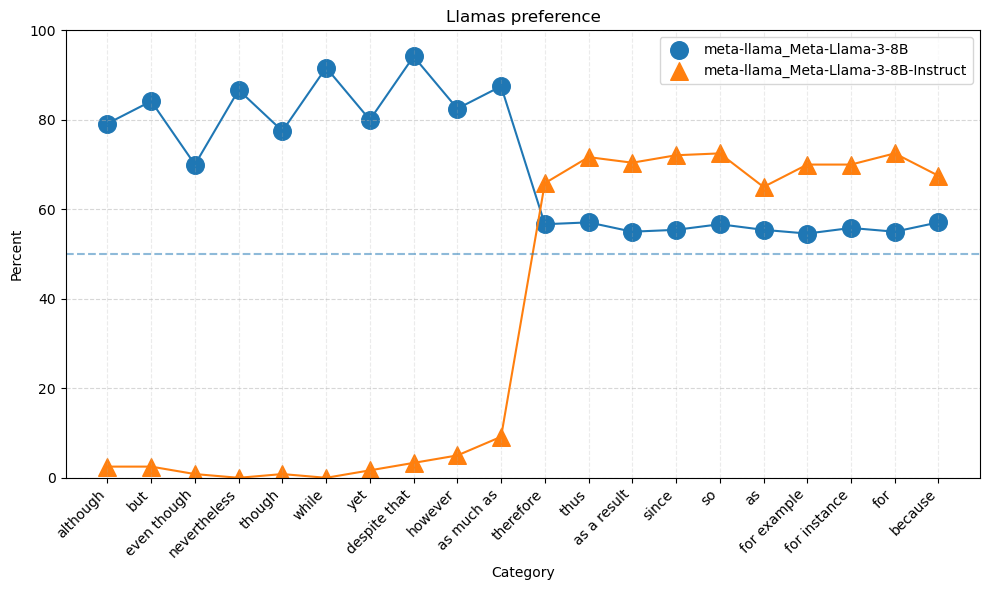

In [415]:
scatter(x=x_pref, y=y_pref_llamas, series_labels=llama_names, it=llamas_it, sizes=llamas_sizes, title="Llamas preference", connected=connected, x_grid=x_grid)

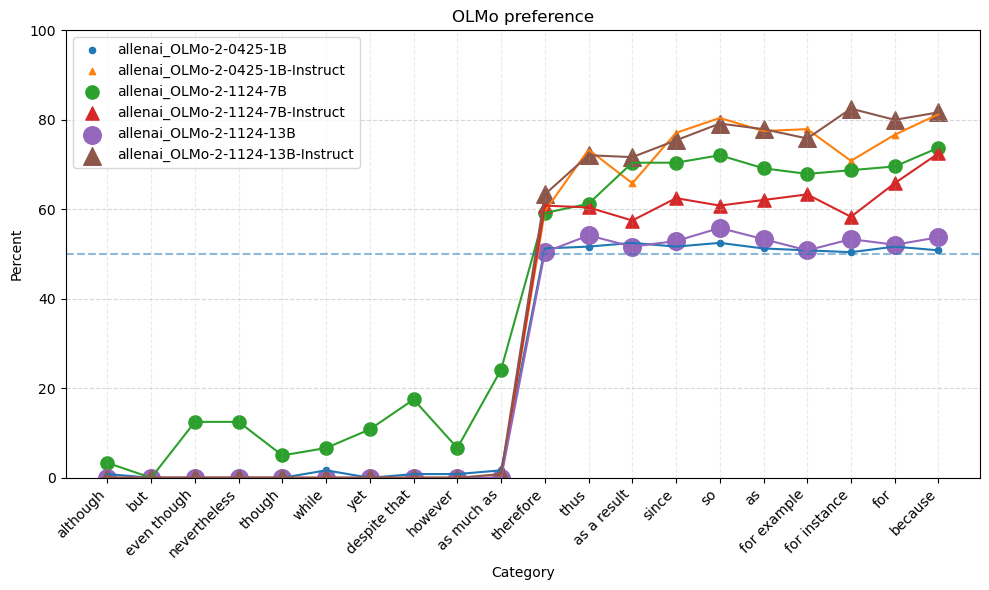

In [416]:
scatter(x=x_pref, y=y_pref_olmos, series_labels=olmo_names, it=olmos_it,  sizes=olmos_sizes, title="OLMo preference", connected=connected, x_grid=x_grid)

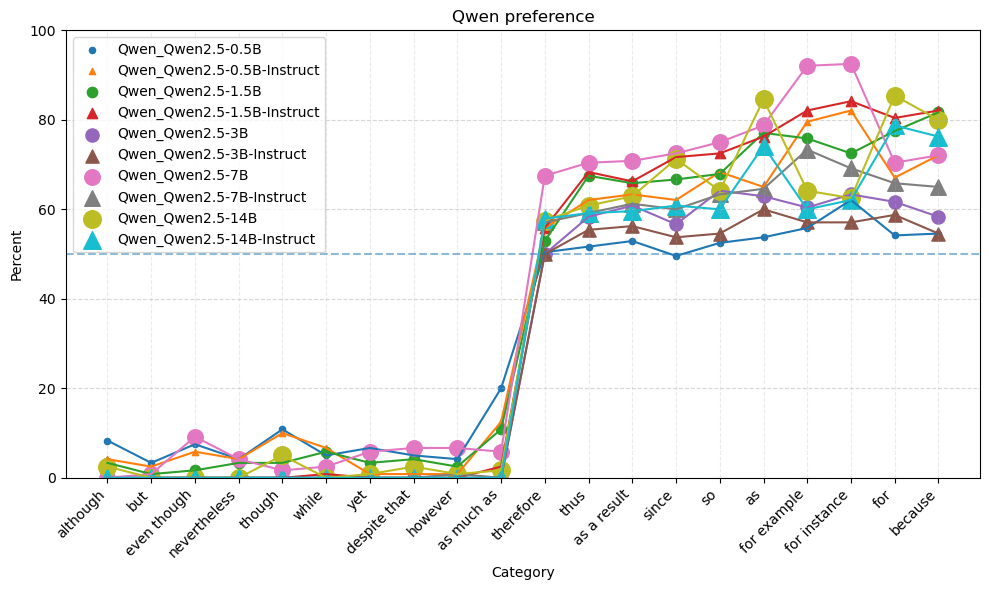

In [417]:
scatter(x=x_pref, y=y_pref_qwens, series_labels=qwen_names, it=qwens_it,  sizes=qwens_sizes, title="Qwen preference", connected=connected, x_grid=x_grid)

## Instantiation

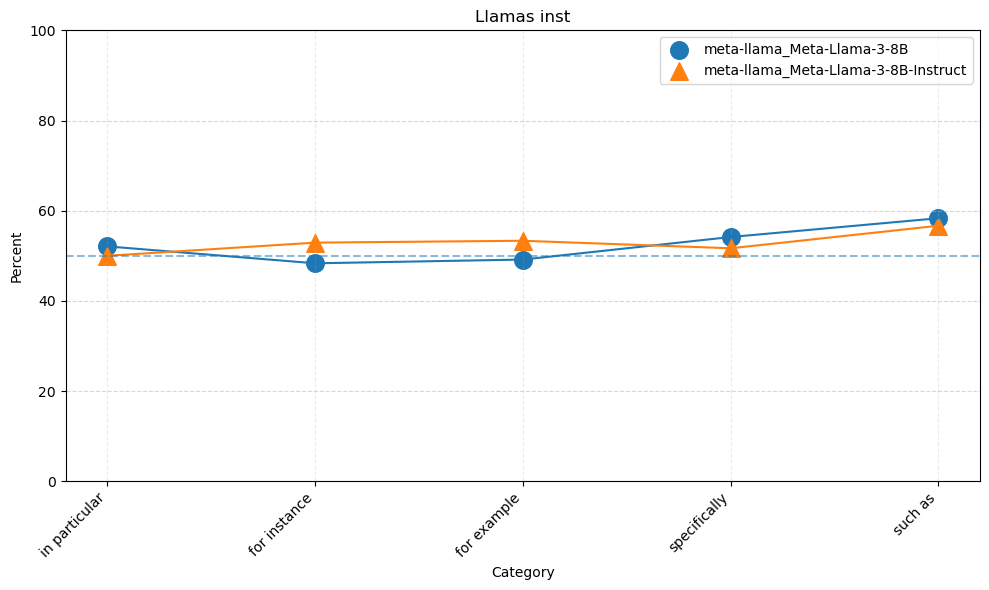

In [418]:
scatter(x=x_inst, y=y_inst_llamas, series_labels=llama_names, it=llamas_it,  sizes=llamas_sizes, title="Llamas inst", connected=connected, x_grid=x_grid)

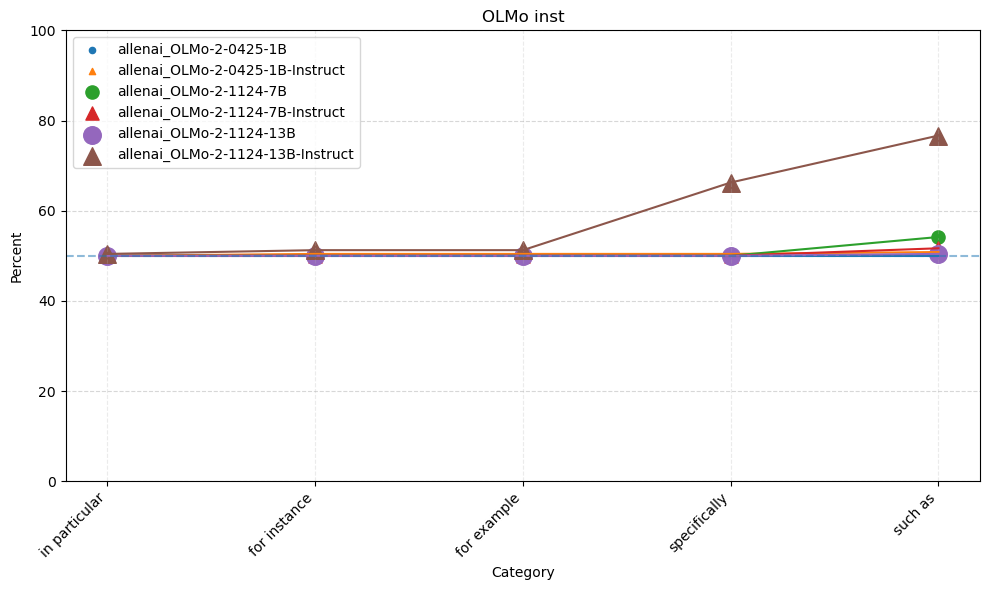

In [419]:
scatter(x=x_inst, y=y_inst_olmos, series_labels=olmo_names, it=olmos_it,  sizes=olmos_sizes, title="OLMo inst", connected=connected, x_grid=x_grid)

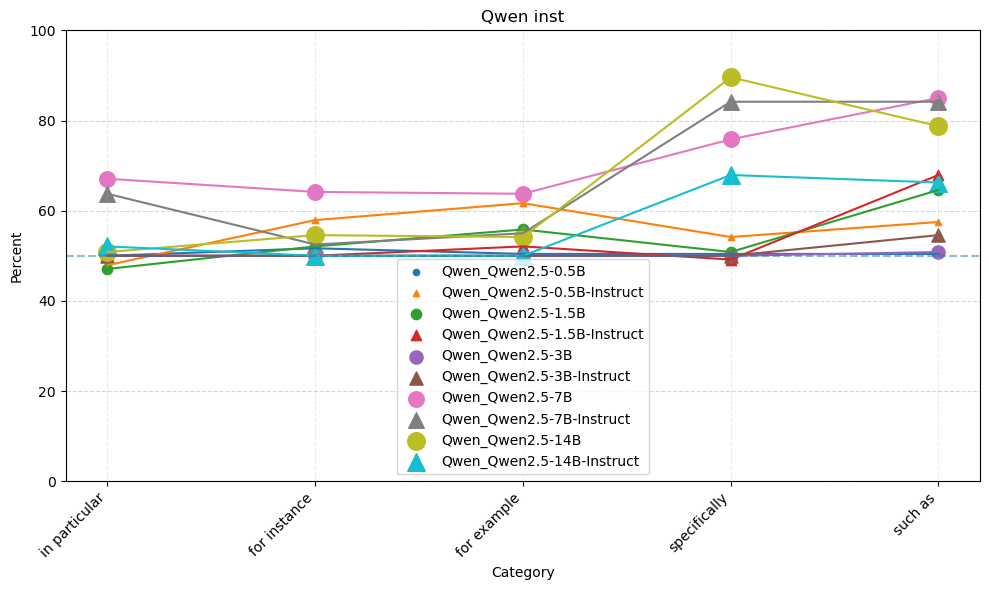

In [420]:
scatter(x=x_inst, y=y_inst_qwens, series_labels=qwen_names, it=qwens_it,  sizes=qwens_sizes, title="Qwen inst", connected=connected, x_grid=x_grid)

## Temporal

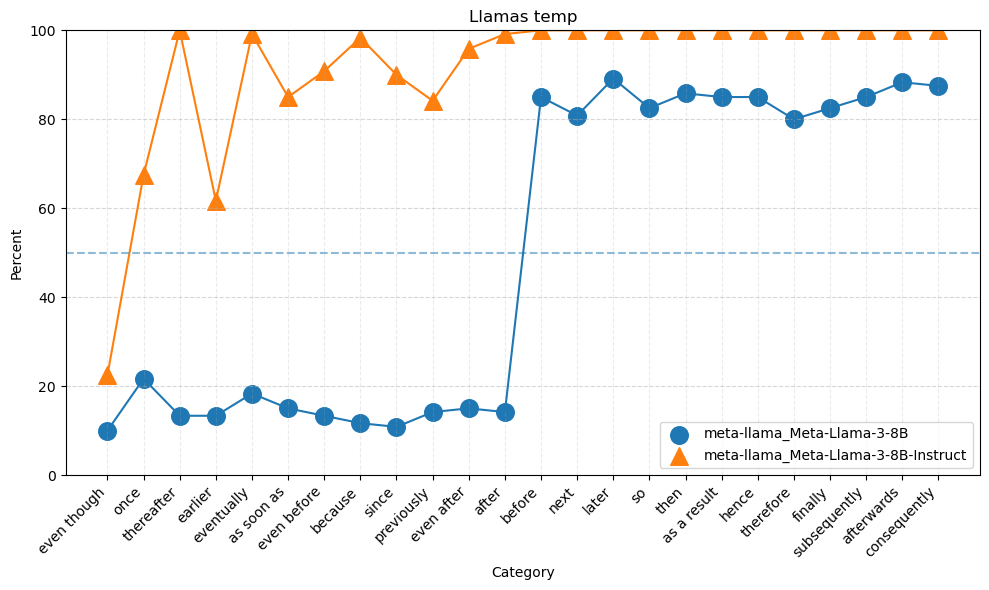

In [421]:
scatter(x=x_temp, y=y_temp_llamas, series_labels=llama_names, it=llamas_it,  sizes=llamas_sizes, title="Llamas temp", connected=connected, x_grid=x_grid)

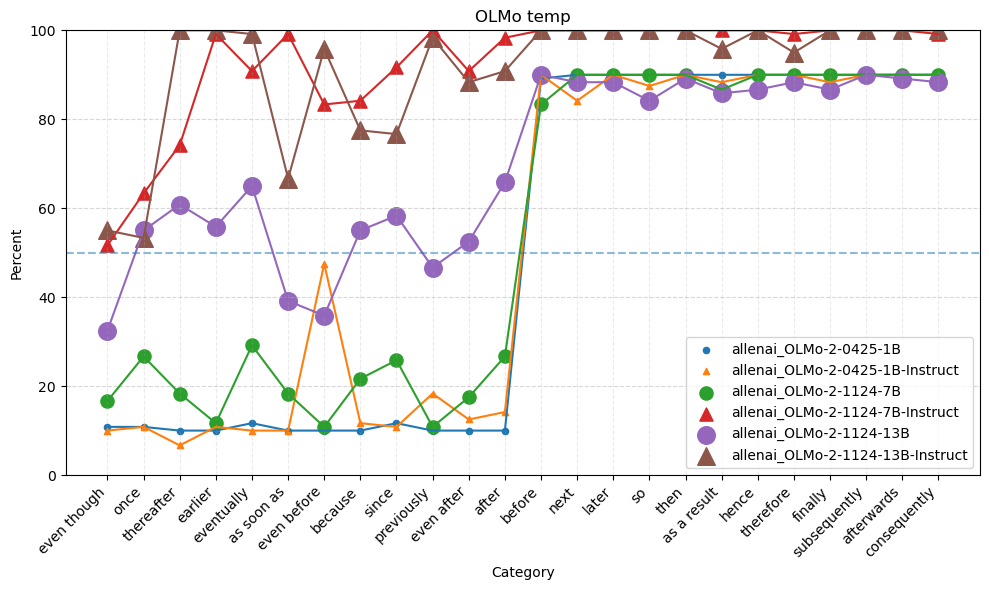

In [422]:
scatter(x=x_temp, y=y_temp_olmos, series_labels=olmo_names, it=olmos_it,  sizes=olmos_sizes, title="OLMo temp", connected=connected, x_grid=x_grid)

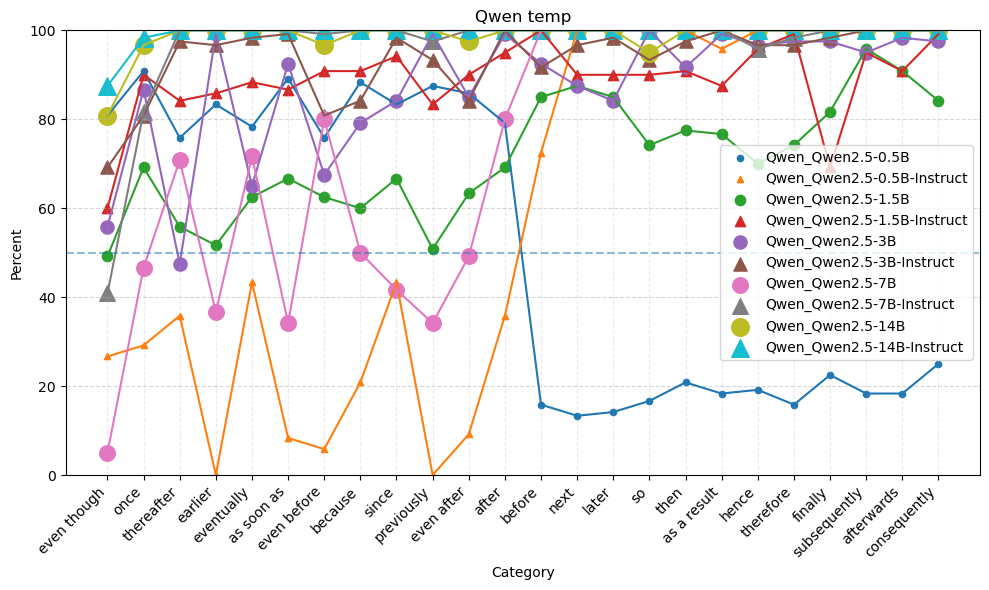

In [423]:
scatter(x=x_temp, y=y_temp_qwens, series_labels=qwen_names, it=qwens_it,  sizes=qwens_sizes, title="Qwen temp", connected=connected, x_grid=x_grid)

## Naives

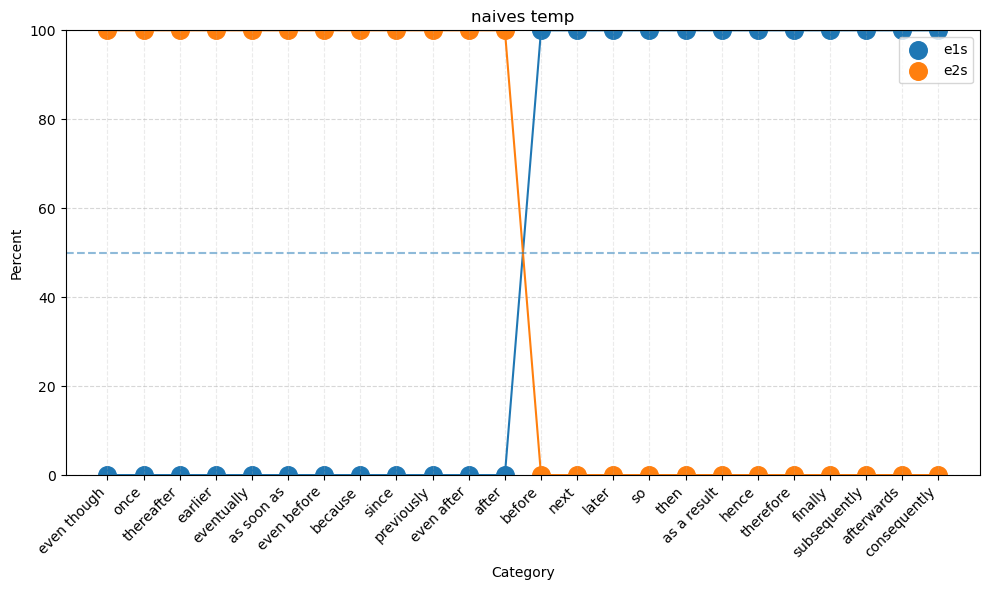

In [424]:
scatter(x=x_temp, y=y_temp_naives, series_labels=naives_names, it=naives_it,  sizes=naives_sizes, title="naives temp", connected=connected, x_grid=x_grid)